# 03b — Rectified Flow Training

Train a **Rectified Flow** model on the same data pipeline as `03_diffusion_training.ipynb`.
Shares the `DiffusionTransformer1D` backbone; only the generative process and training loop differ.

| Item | Value |
|------|-------|
| Process | Linear interpolation  x_t = (1−t)·x₀ + t·ε,  t ∈ [0,1] |
| Loss | MSE velocity + λ·freq  (λ=0.05) |
| Sampler | Euler ODE, 50 steps  (t: 1→0) |
| CFG | v_guided = (1+s)·v_cond − s·v_uncond |
| Backbone | DiffusionTransformer1D (identical to DDPM run) |

**Prerequisites**: run `02_clustering.ipynb` to produce `clusters.csv`.

In [1]:
# ── Environment bootstrap (same as notebook 03) ──────────────────────────────
import importlib
import importlib.util
import inspect
import shutil
import subprocess
import sys
import tempfile
import urllib.request
import zipfile
from dataclasses import dataclass
from pathlib import Path


def clone_repo(repo_url, target_dir):
    result = subprocess.run(
        ['git', 'clone', '--depth', '1', repo_url, str(target_dir)],
        capture_output=True, text=True,
    )
    if result.returncode != 0:
        raise RuntimeError(result.stderr.strip() or 'git clone failed')


def download_repo_archive(archive_url, runtime_dir, repo_dir, extract_dir, archive_path):
    if archive_path.exists():
        archive_path.unlink()
    if extract_dir.exists():
        shutil.rmtree(extract_dir)
    urllib.request.urlretrieve(archive_url, archive_path)
    with zipfile.ZipFile(archive_path, 'r') as archive:
        archive.extractall(runtime_dir)
    if repo_dir.exists():
        shutil.rmtree(repo_dir)
    shutil.move(str(extract_dir), str(repo_dir))


def _is_colab():
    return importlib.util.find_spec('google.colab') is not None


def find_or_bootstrap_repo_root():
    candidates = [
        Path('/home/nicola/Desktop/Supsi/tesina'),
        Path.cwd().resolve(),
        Path('/content/tesina'),
        Path('/tmp/vscode-colab/tesina'),
    ]
    for base in candidates:
        for candidate in [base, *base.parents]:
            if (candidate / 'src').exists() and (candidate / 'data').exists():
                return candidate

    if _is_colab():
        runtime_dir = Path('/content')
        repo_dir = runtime_dir / 'tesina'
    else:
        runtime_dir = Path(tempfile.gettempdir()) / 'vscode-colab'
        repo_dir = runtime_dir / 'tesina'

    archive_path = runtime_dir / 'tesina.zip'
    extract_dir = runtime_dir / 'tesina-master'
    repo_url = 'https://github.com/ncapac/tesina.git'
    archive_url = 'https://codeload.github.com/ncapac/tesina/zip/refs/heads/master'

    runtime_dir.mkdir(parents=True, exist_ok=True)
    if repo_dir.exists() and not (repo_dir / 'src').exists():
        shutil.rmtree(repo_dir)
    if not repo_dir.exists():
        try:
            clone_repo(repo_url, repo_dir)
        except Exception:
            download_repo_archive(archive_url, runtime_dir, repo_dir, extract_dir, archive_path)
    if (repo_dir / 'src').exists() and (repo_dir / 'data').exists():
        return repo_dir
    raise RuntimeError('Could not locate or bootstrap the tesina project root.')


REPO_ROOT = find_or_bootstrap_repo_root()

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import equinox as eqx

# Reload src modules so that edits to source files take effect without kernel restart
import src.data.loader, src.data.dataset
import src.models.transformer1d, src.models.rectified_flow
import src.training.train_rf
importlib.reload(src.data.loader)
importlib.reload(src.data.dataset)
importlib.reload(src.models.transformer1d)
importlib.reload(src.models.rectified_flow)
importlib.reload(src.training.train_rf)

try:
    import src.runtime_paths
    importlib.reload(src.runtime_paths)
    from src.runtime_paths import prepare_artifact_dirs
except ModuleNotFoundError:
    @dataclass(frozen=True)
    class _ArtifactPaths:
        repo_root: Path
        data_dir: Path
        checkpoints_dir: Path
        results_root: Path
        run_results_dir: Path

    def prepare_artifact_dirs(repo_root: str | Path, experiment: str | None = None) -> _ArtifactPaths:
        root = Path(repo_root).expanduser().resolve()
        data_dir = root / 'data'
        checkpoints_dir = root / 'checkpoints'
        results_root = root / 'results'
        run_results_dir = results_root if not experiment else results_root / experiment
        for directory in (checkpoints_dir, results_root, run_results_dir):
            directory.mkdir(parents=True, exist_ok=True)
        return _ArtifactPaths(
            repo_root=root,
            data_dir=data_dir,
            checkpoints_dir=checkpoints_dir,
            results_root=results_root,
            run_results_dir=run_results_dir,
        )

from src.data.loader import load_raw, compute_stats, normalize, denormalize
from src.data.dataset import make_windows, train_val_split, numpy_dataloader
from src.models.transformer1d import DiffusionTransformer1D
from src.models.rectified_flow import RectifiedFlowProcess
from src.training.train_rf import RFTrainer

if 'balance_condition_cols' not in inspect.signature(numpy_dataloader).parameters:
    class _BalancedInfiniteLoader:
        def __init__(
            self,
            xs: np.ndarray,
            cs: np.ndarray,
            batch_size: int,
            balance_condition_cols: tuple[int, ...],
            shuffle: bool,
            rng: np.random.Generator,
        ):
            grouped_indices = {}
            for idx, row in enumerate(cs):
                key = tuple(int(row[col]) for col in balance_condition_cols)
                grouped_indices.setdefault(key, []).append(idx)

            self.group_keys = sorted(grouped_indices)
            self.grouped_indices = {
                key: np.asarray(indices, dtype=np.int32)
                for key, indices in grouped_indices.items()
            }
            self.batch_size = batch_size
            self.shuffle = shuffle
            self.rng = rng
            self.xs = xs
            self.cs = cs
            self.epoch_len = max(1, len(xs) // batch_size)

        def __iter__(self):
            return self

        def __next__(self):
            n_groups = len(self.group_keys)
            base = self.batch_size // n_groups
            remainder = self.batch_size % n_groups
            batch_indices = []

            for group_idx, key in enumerate(self.group_keys):
                n_take = base + int(group_idx < remainder)
                if n_take == 0:
                    continue
                pool = self.grouped_indices[key]
                sampled = self.rng.choice(pool, size=n_take, replace=len(pool) < n_take)
                batch_indices.append(sampled)

            batch_indices = np.concatenate(batch_indices, axis=0)
            if self.shuffle:
                self.rng.shuffle(batch_indices)
            return self.xs[batch_indices], self.cs[batch_indices]

    _base_numpy_dataloader = numpy_dataloader

    def numpy_dataloader(
        xs: np.ndarray,
        cs: np.ndarray,
        batch_size: int,
        shuffle: bool = True,
        balance_condition_cols: tuple[int, ...] | None = None,
        rng: int | np.random.Generator = 0,
    ):
        if isinstance(rng, int):
            rng = np.random.default_rng(rng)
        if balance_condition_cols is not None:
            return _BalancedInfiniteLoader(
                xs,
                cs,
                batch_size,
                tuple(balance_condition_cols),
                shuffle,
                rng,
            )
        return _base_numpy_dataloader(xs, cs, batch_size=batch_size, shuffle=shuffle, rng=rng)

ARTIFACTS = prepare_artifact_dirs(REPO_ROOT, experiment='rectified_flow')
DATA_DIR = ARTIFACTS.data_dir
CHECKPOINT_DIR = ARTIFACTS.checkpoints_dir
RESULTS_DIR = ARTIFACTS.run_results_dir

plt.rcParams['figure.dpi'] = 110
print('Project root :', REPO_ROOT)
print('Checkpoints  :', CHECKPOINT_DIR)
print('Results dir  :', RESULTS_DIR)
print('JAX devices  :', jax.devices())

# ── Training budget ──────────────────────────────────────────────────────────
QUICK_RUN  = False         # full GPU run
N_EPOCHS   = 5   if QUICK_RUN else 200
BATCH_SIZE = 256           # match DDPM throughput on T4-class GPUs
LR         = 2e-3          # sqrt-scaled for the larger batch
WARMUP_STEPS   = 300  if QUICK_RUN else 2000
GUIDANCE_SCALE = 1.5

CHECKPOINT_NAME = 'rf_best_model.pkl'

Project root : /content/tesina
Checkpoints  : /content/tesina/checkpoints
Results dir  : /content/tesina/results/rectified_flow
JAX devices  : [CudaDevice(id=0)]


## 1. Load & prepare data

In [2]:
df = load_raw(DATA_DIR / 'power.pk')

clusters_df    = pd.read_csv(DATA_DIR / 'clusters.csv')
cluster_labels = clusters_df['cluster_id'].values
N_CLUSTERS     = int(cluster_labels.max()) + 1

print(f'{df.shape[1]} meters, {N_CLUSTERS} clusters')
print(f'Cluster sizes: { {c: (cluster_labels==c).sum() for c in range(N_CLUSTERS)} }')

timestamps = df.index if isinstance(df.index, pd.DatetimeIndex) else None

stats    = compute_stats(df, cluster_labels)
df_norm  = normalize(df, stats, cluster_labels)

xs, cs, mid = make_windows(df_norm, cluster_labels, timestamps)
print(f'Windows: xs={xs.shape}  cs={cs.shape}')

x_train, c_train, x_val, c_val = train_val_split(xs, cs, mid, n_meters=df.shape[1])
print(f'Train: {x_train.shape[0]}  Val: {x_val.shape[0]}')

print('\nWindows per cluster (train):')
for cid in range(N_CLUSTERS):
    n_tr = (c_train[:, 0] == cid).sum()
    n_va = (c_val[:,   0] == cid).sum()
    print(f'  Cluster {cid}: train={n_tr:6d}  val={n_va:5d}')

print('\nNormalised stats per cluster (train):')
for cid in range(N_CLUSTERS):
    mask = c_train[:, 0] == cid
    vals = x_train[mask].ravel()
    print(f'  Cluster {cid}: mean={vals.mean():+.3f}  std={vals.std():.3f}')

321 meters, 3 clusters
Cluster sizes: {0: np.int64(183), 1: np.int64(34), 2: np.int64(104)}
Windows: xs=(351816, 24)  cs=(351816, 4)
Train: 299208  Val: 52608

Windows per cluster (train):
  Cluster 0: train=169880  val=30688
  Cluster 1: train= 31784  val= 5480
  Cluster 2: train= 97544  val=16440

Normalised stats per cluster (train):
  Cluster 0: mean=+0.025  std=1.077
  Cluster 1: mean=+0.031  std=1.080
  Cluster 2: mean=+0.024  std=1.066


## 2. Model & RF process setup

In [3]:
key = jax.random.PRNGKey(42)   # different seed from DDPM to get independent init

model = DiffusionTransformer1D(
    seq_len     = 24,
    d_model     = 128,
    n_heads     = 4,
    n_layers    = 4,
    d_ff        = 256,
    n_clusters  = N_CLUSTERS,
    n_day_types = 2,
    n_months    = 12,
    n_dow       = 7,
    key         = key,
)

rf = RectifiedFlowProcess(freq_loss_weight=0.05)

total_steps = N_EPOCHS * max(1, len(x_train) // BATCH_SIZE)
trainer = RFTrainer(
    model, rf,
    lr            = LR,
    warmup_steps  = WARMUP_STEPS,
    total_steps   = total_steps,
    checkpoint_dir= str(CHECKPOINT_DIR),
)

n_params = sum(
    x.size for x in jax.tree_util.tree_leaves(eqx.filter(model, eqx.is_array))
)
print(f'Model params : {n_params:,}')
print(f'JAX device   : {jax.devices()[0]}')
print(f'Process      : Rectified Flow  (t ~ Uniform[0,1])')
print(f'Conditioning : c = [cluster_id, day_type, month, dow]  shape=(4,)')

# Load existing checkpoint if available (resume training)
rf_ckpt = CHECKPOINT_DIR / CHECKPOINT_NAME
if rf_ckpt.exists():
    trainer.load(CHECKPOINT_NAME)
    print(f'Resumed from checkpoint (step {trainer.step})')
else:
    print('No existing checkpoint — starting from scratch.')

Model params : 846,338
JAX device   : cuda:0
Process      : Rectified Flow  (t ~ Uniform[0,1])
Conditioning : c = [cluster_id, day_type, month, dow]  shape=(4,)
No existing checkpoint — starting from scratch.


## 3. Training

In [4]:
BALANCE_TRAINING = True
LOG_CLUSTER_LOSSES = False
VAL_EVERY = 2
VAL_BATCHES = 64

train_balance_cols = (0, 1) if BALANCE_TRAINING else None

train_loader = numpy_dataloader(
    x_train,
    c_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    balance_condition_cols=train_balance_cols,
    rng=np.random.default_rng(10),
)
val_loader = numpy_dataloader(
    x_val,
    c_val,
    batch_size=BATCH_SIZE,
    shuffle=False,
    rng=np.random.default_rng(11),
)

print(f'Balanced train sampling : {BALANCE_TRAINING}  (condition cols={train_balance_cols})')
print(f'Per-batch cluster diagnostics : {LOG_CLUSTER_LOSSES}')
print(f'Validation schedule : every {VAL_EVERY} epoch(s), {VAL_BATCHES} batches per pass')

trainer.fit(
    train_loader    = train_loader,
    val_loader      = val_loader,
    n_epochs        = N_EPOCHS,
    val_every       = VAL_EVERY,
    save_every      = max(1, N_EPOCHS // 5),
    log_every_steps = max(1, len(x_train) // BATCH_SIZE // 4),
    val_batches     = VAL_BATCHES,
    log_cluster_losses = LOG_CLUSTER_LOSSES,
)

train_losses = trainer.train_losses
val_losses   = trainer.val_losses
print(f'\nDone. Final train loss: {train_losses[-1]:.4f}  val loss: {val_losses[-1]:.4f}')

Balanced train sampling : True  (condition cols=(0, 1))
Per-batch cluster diagnostics : False
Validation schedule : every 2 epoch(s), 64 batches per pass
  step    292  loss 3.2954
  step    584  loss 0.5381
  step    876  loss 0.6965
  step   1168  loss 1.1098
Epoch   1/200  train_loss 1.4586  [55.9s]
  step   1460  loss 0.3226
  step   1752  loss 0.3505
  step   2044  loss 0.4821
  step   2336  loss 0.5676
Epoch   2/200  train_loss 0.7193  val_loss 0.2504  [37.7s]
  step   2628  loss 0.3696
  step   2920  loss 0.2475
  step   3212  loss 0.3001
  step   3504  loss 0.4999
Epoch   3/200  train_loss 0.6492  [33.5s]
  step   3796  loss 0.3778
  step   4088  loss 0.8529
  step   4380  loss 0.8778
  step   4672  loss 0.3420
Epoch   4/200  train_loss 0.6412  val_loss 0.2888  [33.7s]
  step   4964  loss 0.4083
  step   5256  loss 0.6989
  step   5548  loss 1.3702
  step   5840  loss 0.3083
Epoch   5/200  train_loss 0.6093  [33.6s]
  step   6132  loss 0.4322
  step   6424  loss 0.3120
  step  

## 4. Loss curves

Saved -> /content/tesina/results/rectified_flow/loss_curves.png


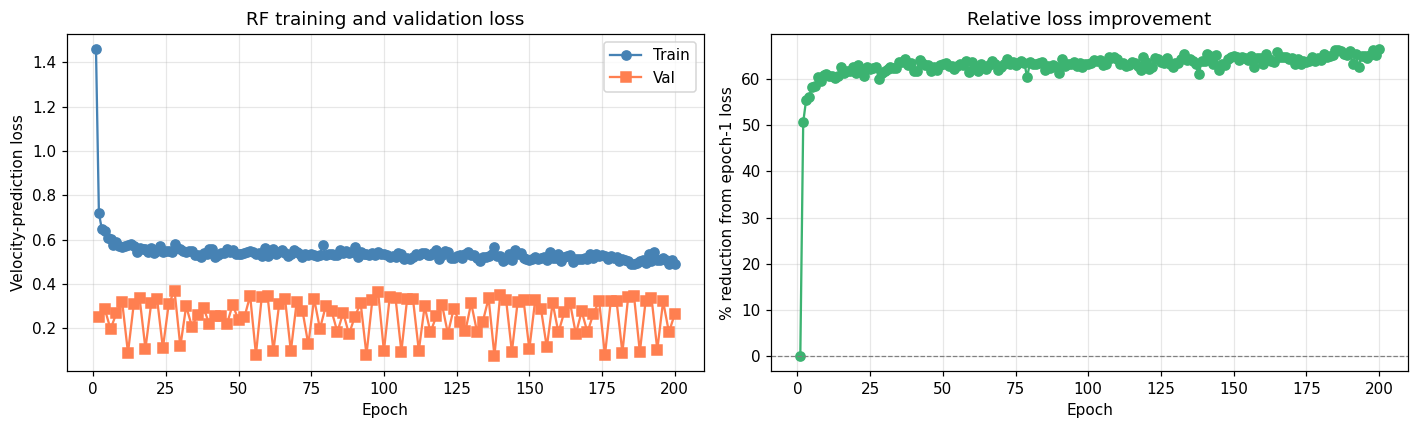

Epoch 1 loss : 1.4586
Final loss   : 0.4896  (66.4% reduction)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

epochs = range(1, len(train_losses) + 1)
val_epochs = list(range(VAL_EVERY, VAL_EVERY * len(val_losses) + 1, VAL_EVERY))
axes[0].plot(list(epochs), train_losses, 'o-', color='steelblue', lw=1.5, label='Train')
axes[0].plot(val_epochs, val_losses, 's-', color='coral', lw=1.5, label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Velocity-prediction loss')
axes[0].set_title('RF training and validation loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

if len(train_losses) > 1:
    rel = [(train_losses[0] - l) / train_losses[0] * 100 for l in train_losses]
    axes[1].plot(list(epochs), rel, 'o-', color='mediumseagreen', lw=1.5)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('% reduction from epoch-1 loss')
    axes[1].set_title('Relative loss improvement')
    axes[1].grid(True, alpha=0.3)
    axes[1].axhline(0, color='grey', ls='--', lw=0.8)

plt.tight_layout()
loss_curves_path = RESULTS_DIR / 'loss_curves.png'
fig.savefig(loss_curves_path, dpi=150, bbox_inches='tight')
print(f'Saved -> {loss_curves_path}')
plt.show()
print(f'Epoch 1 loss : {train_losses[0]:.4f}')
print(f'Final loss   : {train_losses[-1]:.4f}  '
      f'({(train_losses[0]-train_losses[-1])/train_losses[0]*100:.1f}% reduction)')
if QUICK_RUN:
    print('\nWARNING: QUICK_RUN=True: only 5 epochs. For thesis-quality results,')
    print('  set QUICK_RUN=False and run on GPU (~200 epochs).')

# -- Per-cluster loss curves -------------------------------------------------
if trainer.cluster_losses:
    fig2, ax2 = plt.subplots(figsize=(9, 3.5))
    colors_cl = ['steelblue', 'coral', 'mediumseagreen']
    cluster_epochs = list(range(VAL_EVERY, VAL_EVERY * len(next(iter(trainer.cluster_losses.values()))) + 1, VAL_EVERY))
    for cid, losses in sorted(trainer.cluster_losses.items()):
        ax2.plot(cluster_epochs[:len(losses)], losses, 'o-',
                 color=colors_cl[cid % len(colors_cl)], lw=1.5, label=f'Cluster {cid}')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Eval loss')
    ax2.set_title('Per-cluster validation loss (RF)')
    ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    cluster_loss_path = RESULTS_DIR / 'cluster_loss_curves.png'
    fig2.savefig(cluster_loss_path, dpi=150, bbox_inches='tight')
    print(f'Saved -> {cluster_loss_path}')
    plt.show()

## 5. Quick sample inspection (Euler 50 steps)

Saved -> /content/tesina/results/rectified_flow/sample_inspection.png


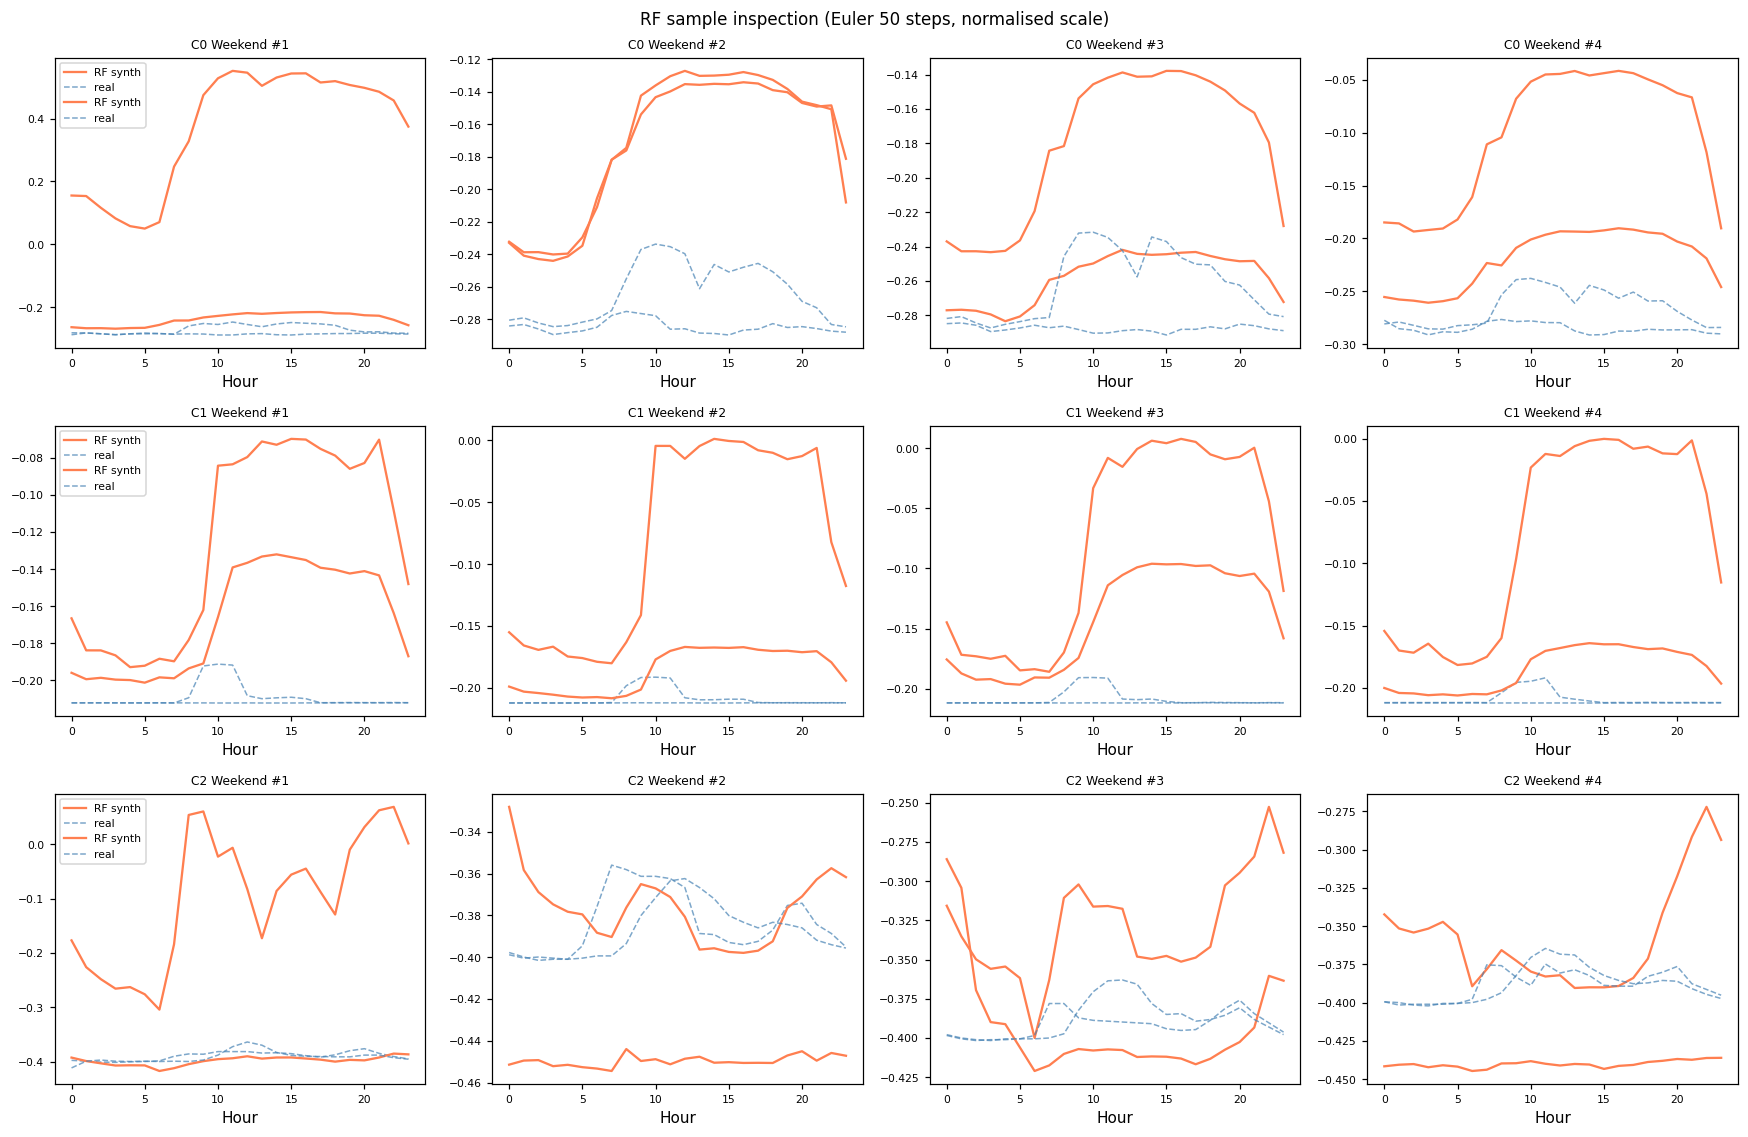

In [7]:
hours  = np.arange(24)
n_show = 4

fig, axes = plt.subplots(N_CLUSTERS, 4, figsize=(16, 3.5 * N_CLUSTERS))
if N_CLUSTERS == 1:
    axes = axes[None, :]
day_labels = ['Weekday', 'Weekend']

for cid in range(N_CLUSTERS):
    for dt in range(2):
        rep_dow  = 1 if dt == 0 else 5
        c_batch  = jnp.array([[cid, dt, 5, rep_dow]] * n_show, dtype=jnp.int32)
        gen_key  = jax.random.PRNGKey(cid * 10 + dt + 100)
        samples_norm = rf.sample(
            trainer.model, c_batch,
            seq_len=24, batch_size=n_show,
            key=gen_key, n_steps=50, guidance_scale=GUIDANCE_SCALE,
        )
        samples_norm = np.array(samples_norm)

        real_mask   = (c_train[:, 0] == cid) & (c_train[:, 1] == dt)
        real_sample = x_train[real_mask][:n_show] if real_mask.sum() > 0 else None

        for k in range(n_show):
            ax = axes[cid, k]
            ax.plot(hours, samples_norm[k], color='coral',     lw=1.5, label='RF synth')
            if real_sample is not None and k < len(real_sample):
                ax.plot(hours, real_sample[k], color='steelblue', lw=1, ls='--',
                        alpha=0.7, label='real')
            ax.set_title(f'C{cid} {day_labels[dt]} #{k+1}', fontsize=8)
            ax.set_xlabel('Hour'); ax.tick_params(labelsize=7)
            if k == 0:
                ax.legend(fontsize=7)

plt.suptitle('RF sample inspection (Euler 50 steps, normalised scale)', fontsize=11)
plt.tight_layout()
sample_inspection_path = RESULTS_DIR / 'sample_inspection.png'
fig.savefig(sample_inspection_path, dpi=150, bbox_inches='tight')
print(f'Saved -> {sample_inspection_path}')
plt.show()

## 6. Denormalised comparison

Saved -> /content/tesina/results/rectified_flow/denormalized_comparison.png


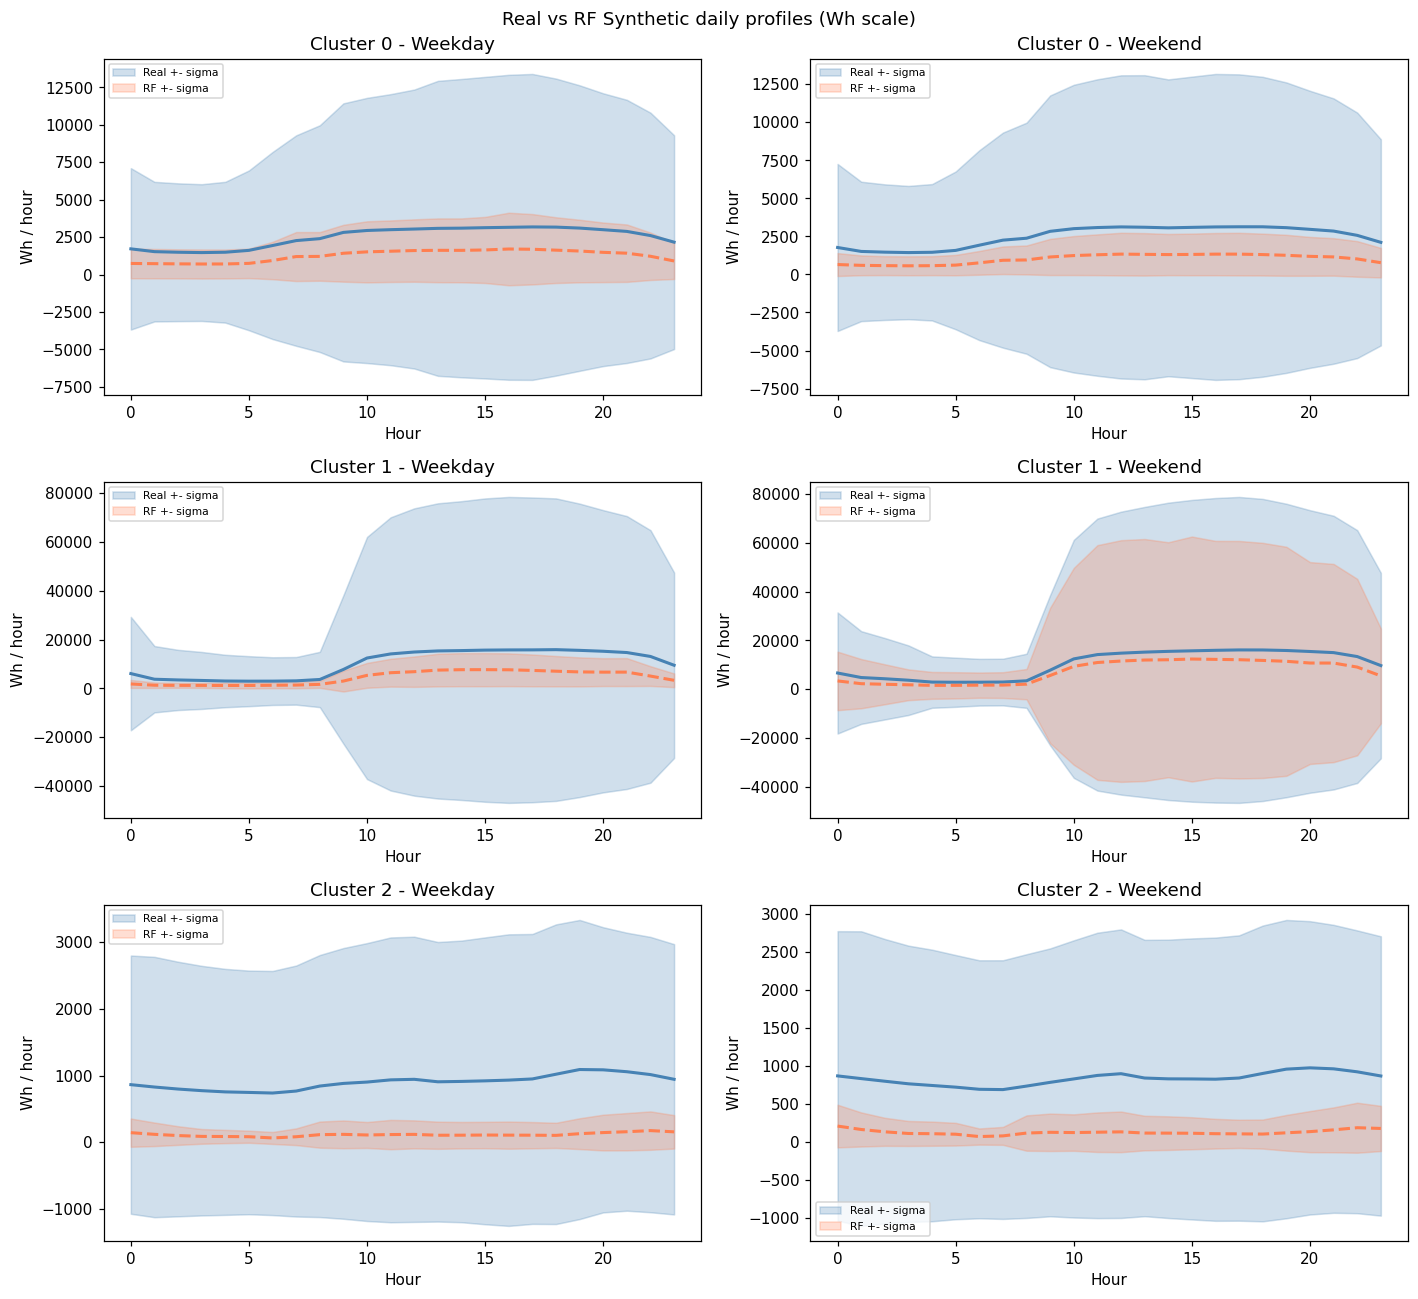

In [8]:
hours = np.arange(24)
fig, axes = plt.subplots(N_CLUSTERS, 2, figsize=(13, 4 * N_CLUSTERS))
if N_CLUSTERS == 1:
    axes = axes[None, :]

for cid in range(N_CLUSTERS):
    for dt, day_name in enumerate(['Weekday', 'Weekend']):
        rep_dow = 1 if dt == 0 else 5
        c_batch = jnp.array([[cid, dt, 5, rep_dow]] * 100, dtype=jnp.int32)
        synth_norm = rf.sample(
            trainer.model, c_batch,
            seq_len=24, batch_size=100,
            key=jax.random.PRNGKey(cid * 100 + dt),
            n_steps=50, guidance_scale=GUIDANCE_SCALE,
        )
        synth_dn = denormalize(np.array(synth_norm), cid, stats)

        real_mask = (c_train[:, 0] == cid) & (c_train[:, 1] == dt)
        real_dn   = denormalize(x_train[real_mask], cid, stats)

        ax = axes[cid, dt]
        mu_r, s_r = real_dn.mean(0),  real_dn.std(0)
        mu_s, s_s = synth_dn.mean(0), synth_dn.std(0)
        ax.fill_between(hours, mu_r - s_r, mu_r + s_r, alpha=0.25, color='steelblue', label='Real +- sigma')
        ax.fill_between(hours, mu_s - s_s, mu_s + s_s, alpha=0.25, color='coral',     label='RF +- sigma')
        ax.plot(hours, mu_r, color='steelblue', lw=2)
        ax.plot(hours, mu_s, color='coral',     lw=2, ls='--')
        ax.set_title(f'Cluster {cid} - {day_name}')
        ax.set_xlabel('Hour'); ax.set_ylabel('Wh / hour')
        ax.legend(fontsize=7)

plt.suptitle('Real vs RF Synthetic daily profiles (Wh scale)', fontsize=12)
plt.tight_layout()
denormalized_path = RESULTS_DIR / 'denormalized_comparison.png'
fig.savefig(denormalized_path, dpi=150, bbox_inches='tight')
print(f'Saved -> {denormalized_path}')
plt.show()

## 7. Save checkpoint

In [9]:
trainer.save(CHECKPOINT_NAME)

n_params = sum(
    x.size for x in jax.tree_util.tree_leaves(eqx.filter(trainer.model, eqx.is_array))
)
print(f"  Parameters : {n_params:,}")
print(f"  Epochs done: {N_EPOCHS}  (QUICK_RUN={QUICK_RUN})")
if trainer.val_losses:
    print(f"  Best val   : {min(trainer.val_losses):.4f}  "
          f"(epoch {np.argmin(trainer.val_losses)+1})")

  ✓ checkpoint saved → /content/tesina/checkpoints/rf_best_model.pkl
  Parameters : 846,338
  Epochs done: 200  (QUICK_RUN=False)
  Best val   : 0.0760  (epoch 69)


In [10]:
# -- Artifact summary ---------------------------------------------------------
checkpoint_path = CHECKPOINT_DIR / CHECKPOINT_NAME
if not checkpoint_path.exists():
    trainer.save(CHECKPOINT_NAME)

file_mb = checkpoint_path.stat().st_size / 1e6
print(f'  Checkpoint present -> {checkpoint_path}  ({file_mb:.1f} MB)')
print(f'  Results directory  -> {RESULTS_DIR}')
print('  Artifacts are saved inside the repository working tree used by this kernel.')
if _is_colab():
    print('  If you need to keep them after the runtime resets, copy or export them out manually.')

  Checkpoint present -> /content/tesina/checkpoints/rf_best_model.pkl  (10.2 MB)
  Results directory  -> /content/tesina/results/rectified_flow
  Artifacts are saved inside the repository working tree used by this kernel.
  If you need to keep them after the runtime resets, copy or export them out manually.


In [13]:
import importlib
import json
import os
import shutil
import tarfile
from datetime import datetime, UTC
from pathlib import Path

# -- Package artifacts for preservation --------------------------------------
EXPORTS_DIR = REPO_ROOT / 'results' / 'exports'
EXPORTS_DIR.mkdir(parents=True, exist_ok=True)

DOWNLOAD_ARCHIVE_IN_COLAB = True
LOCAL_REPO_CANDIDATES = [
    Path(os.environ['TESINA_LOCAL_REPO_DIR']) if 'TESINA_LOCAL_REPO_DIR' in os.environ else None,
    Path('/home/nicola/Desktop/Supsi/tesina'),
]

timestamp = datetime.now(UTC).strftime('%Y%m%dT%H%M%SZ')
archive_path = EXPORTS_DIR / f'rf_baseline_{timestamp}.tar.gz'
manifest_path = EXPORTS_DIR / f'rf_baseline_{timestamp}.manifest.json'
restore_local_command = f'python scripts/restore_export_bundle.py results/exports/{archive_path.name}'

paths_to_bundle = [
    CHECKPOINT_DIR / CHECKPOINT_NAME,
    RESULTS_DIR / 'training_summary.json',
    RESULTS_DIR / 'loss_curves.png',
    RESULTS_DIR / 'cluster_loss_curves.png',
    RESULTS_DIR / 'sample_inspection.png',
    RESULTS_DIR / 'denormalized_comparison.png',
]

existing_paths = [path for path in paths_to_bundle if path.exists()]
missing_paths = [str(path) for path in paths_to_bundle if not path.exists()]
if not existing_paths:
    raise FileNotFoundError('No RF artifacts found to package.')

manifest = {
    'repo_root': str(REPO_ROOT),
    'created_utc': timestamp,
    'archive_path': str(archive_path),
    'restore_local_command': restore_local_command,
    'files': [
        {
            'path': str(path),
            'size_bytes': int(path.stat().st_size),
            'relative_to_repo': str(path.relative_to(REPO_ROOT)),
        }
        for path in existing_paths
    ],
    'missing_files': missing_paths,
}

with tarfile.open(archive_path, 'w:gz') as tar:
    for path in existing_paths:
        tar.add(path, arcname=str(path.relative_to(REPO_ROOT)))

with open(manifest_path, 'w', encoding='utf-8') as f:
    json.dump(manifest, f, indent=2)

mirrored_root = None
for candidate in LOCAL_REPO_CANDIDATES:
    if candidate is None:
        continue
    candidate = candidate.expanduser()
    if not candidate.exists():
        continue
    try:
        if candidate.resolve() == REPO_ROOT.resolve():
            continue
    except FileNotFoundError:
        continue
    if not (candidate / 'data').exists():
        continue

    for path in existing_paths:
        destination = candidate / path.relative_to(REPO_ROOT)
        destination.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(path, destination)

    destination_archive = candidate / 'results' / 'exports' / archive_path.name
    destination_manifest = candidate / 'results' / 'exports' / manifest_path.name
    destination_archive.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(archive_path, destination_archive)
    shutil.copy2(manifest_path, destination_manifest)
    mirrored_root = candidate
    break

print(f'Archive  : {archive_path}')
print(f'Manifest : {manifest_path}')
for item in manifest['files']:
    print(f"  - {item['relative_to_repo']}  ({item['size_bytes'] / 1e6:.2f} MB)")
if missing_paths:
    print('Missing optional files:')
    for path in missing_paths:
        print(f'  - {path}')

print('Local restore command:')
print(f'  {restore_local_command}')

if mirrored_root is not None:
    print(f'Local mirror : {mirrored_root}')
    print('  checkpoint and result files were copied into the detected local repo tree.')
else:
    print('Local mirror : not available from this kernel.')
    print('  After downloading, place the archive under results/exports/ in the local repo and run the restore command above.')
    print('  Notebook 05 can also auto-restore the latest RF bundle from results/exports/.')

if _is_colab() and DOWNLOAD_ARCHIVE_IN_COLAB:
    try:
        colab_files = importlib.import_module('google.colab.files')
        colab_files.download(str(archive_path))
        colab_files.download(str(manifest_path))
        print('Browser download triggered for the RF archive and manifest.')
    except Exception as exc:
        print(f'Automatic browser download failed: {exc}')

Archive  : /content/tesina/results/exports/rf_baseline_20260408T153645Z.tar.gz
Manifest : /content/tesina/results/exports/rf_baseline_20260408T153645Z.manifest.json
  - checkpoints/rf_best_model.pkl  (10.18 MB)
  - results/rectified_flow/training_summary.json  (0.01 MB)
  - results/rectified_flow/loss_curves.png  (0.09 MB)
  - results/rectified_flow/sample_inspection.png  (0.39 MB)
  - results/rectified_flow/denormalized_comparison.png  (0.30 MB)
Missing optional files:
  - /content/tesina/results/rectified_flow/cluster_loss_curves.png
Local restore command:
  python scripts/restore_export_bundle.py results/exports/rf_baseline_20260408T153645Z.tar.gz
Local mirror : not available from this kernel.
  After downloading, place the archive under results/exports/ in the local repo and run the restore command above.
  Notebook 05 can also auto-restore the latest RF bundle from results/exports/.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Browser download triggered for the RF archive and manifest.


In [12]:
import json

print('=' * 60)
print('RF TRAINING RUN SUMMARY')
print('=' * 60)
print(f'\n  Process       : Rectified Flow  (t ~ Uniform[0,1])')
print(f'  Epochs        : {N_EPOCHS}  (QUICK_RUN={QUICK_RUN})')
print(f'  Batch size    : {BATCH_SIZE}')
print(f'  Learning rate : {LR}  (cosine schedule, warmup={WARMUP_STEPS})')
print(f'  Steps/epoch   : {max(1, len(x_train) // BATCH_SIZE)}')
print(f'  Model params  : {sum(x.size for x in jax.tree_util.tree_leaves(eqx.filter(trainer.model, eqx.is_array))):,}')

summary = {
    'process': 'rectified_flow',
    'epochs': N_EPOCHS,
    'quick_run': QUICK_RUN,
    'batch_size': BATCH_SIZE,
    'learning_rate': LR,
    'warmup_steps': WARMUP_STEPS,
    'guidance_scale': GUIDANCE_SCALE,
    'n_clusters': N_CLUSTERS,
    'model_params': int(sum(x.size for x in jax.tree_util.tree_leaves(eqx.filter(trainer.model, eqx.is_array)))),
    'device': str(jax.devices()[0]),
    'train_losses': trainer.train_losses,
    'val_losses': trainer.val_losses,
    'cluster_losses': {str(cid): losses for cid, losses in trainer.cluster_losses.items()},
}

if trainer.train_losses:
    first, last = trainer.train_losses[0], trainer.train_losses[-1]
    pct = (first - last) / first * 100
    print(f'\n  Initial loss  : {first:.4f}')
    print(f'  Final loss    : {last:.4f}  ({pct:.1f}% reduction)')
    summary['initial_loss'] = first
    summary['final_loss'] = last
    summary['loss_reduction_pct'] = round(pct, 2)
    if trainer.val_losses:
        best_ep  = int(np.argmin(trainer.val_losses)) + 1
        best_val = min(trainer.val_losses)
        print(f'  Best val loss : {best_val:.4f}  (epoch {best_ep})')
        summary['best_val_loss'] = best_val
        summary['best_val_epoch'] = best_ep

summary_path = RESULTS_DIR / 'training_summary.json'
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2)

print(f'\n  Training device: {jax.devices()[0]}')
print(f'\n  Results saved to {RESULTS_DIR}/')
print('    - training_summary.json')
print('    - loss_curves.png')
print('    - sample_inspection.png')
print('    - denormalized_comparison.png')
if trainer.cluster_losses:
    print('    - cluster_loss_curves.png')
print(f'\n  Next step: run 05_comparison.ipynb after both DDPM and RF are fully trained.')
print('  Expected full-training metric targets (same as DDPM):')
print('    Discriminative accuracy <= 0.55')
print('    ACF L2 distance         <= 0.05')
print('    Wasserstein             <= 0.05')

RF TRAINING RUN SUMMARY

  Process       : Rectified Flow  (t ~ Uniform[0,1])
  Epochs        : 200  (QUICK_RUN=False)
  Batch size    : 256
  Learning rate : 0.002  (cosine schedule, warmup=2000)
  Steps/epoch   : 1168
  Model params  : 846,338

  Initial loss  : 1.4586
  Final loss    : 0.4896  (66.4% reduction)
  Best val loss : 0.0760  (epoch 69)

  Training device: cuda:0

  Results saved to /content/tesina/results/rectified_flow/
    - training_summary.json
    - loss_curves.png
    - sample_inspection.png
    - denormalized_comparison.png

  Next step: run 05_comparison.ipynb after both DDPM and RF are fully trained.
  Expected full-training metric targets (same as DDPM):
    Discriminative accuracy <= 0.55
    ACF L2 distance         <= 0.05
    Wasserstein             <= 0.05
